# Figure 4: how is a transition detected, and what does TetrisCNN keep?

This notebook produces manuscript Fig. 4 (`fig:interpretable_detection`), a six-panel
comparison of unsupervised transition detection and TetrisCNN's sparsified bottleneck, for
the Ising (a)-(c) and XY (d)-(f) datasets. It writes `Plots/Fig4.pdf`.

### The physics

Panels (a) and (d) summarize where five independent, unsupervised methods, learning by
confusion (LBC), the prediction-divergence method (PDM), PCA, UMAP, and distance learning
(DL, applied here with its own native discriminator backbone, not TetrisCNN), place the
transition in each sweep. All five agree closely: $t\approx1.1\,\mu\mathrm{s}$ for Ising and
$t\approx0.625\,\mu\mathrm{s}$ for XY (see the method-comparison appendix). These estimates,
not TetrisCNN, are what defines the classification labels used everywhere else in the
paper.

For Ising, the detected change is the loss of the initial $Z$-polarization, a smooth
crossover, not the later antiferromagnetic phase transition proper. None of the
unsupervised methods here detects that later transition, even though it is visible in some
correlators. This distinction is discussed in the main text and matters when reading panel
(c): the red dashed line marks the crossover TetrisCNN was trained to detect, not the
eventual symmetry-breaking transition.

Panels (b),(e) and (c),(f) show what TetrisCNN does with a classification task built around
that crossover time. Under the L1 sparsity penalty on bottleneck activations, branches
irrelevant to the task are driven down by orders of magnitude during training (b,e),
leaving a handful of active branches whose activations $z_k$ are then tracked across the
sweep (c,f). Ising collapses to a single active branch, $z[\blacksquare]$, the
$Z$-magnetization; XY keeps three, since no single correlator separates its classes as
cleanly.

### What it reads

Two canonical trained runs, one per dataset, both $C_4$-equivariant `smallkernels`
"partition" runs at $\lambda_{\max}=3$: `Plots_data/Ising_C4_smallkernels_lam3_seed42_p2`
(seed 42) and `Plots_data/XY_XZ_C4_smallkernels_lam3_seed46_p2` (seed 46). Every
Ising/XY interpretability result quoted in the paper is read off these same two runs; their
provenance (the original training-log path under the gitignored `logs/` tree) is recorded
in `Plots_data/README.md`. Panels (a,d) additionally read two pickled summaries,
`Plots_data/results_LBC_Lambdamax_{Ising,XY_XZ}_summary*.pkl`, produced by a separate
$\lambda_{\max}$-sweep LBC analysis.


In [1]:
import os

from tetriscnn import PAPER_MPLSTYLE
from tetriscnn.models import ShapeAdaptiveConvNet, SmallModel
from tetriscnn.utils import AttrDict, load_json, DEVICE, kernel_to_latex_pattern
from tetriscnn.datasets import create_datasets

from pathlib import Path
import pickle
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from scipy.optimize import minimize_scalar, brentq
import seaborn as sns

# Paths below (Plots_data/ in, Plots/ out) are relative to the repository root;
# move there so the notebook runs the same from the root or from notebooks/.
os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()))
Path("Plots/SVG").mkdir(parents=True, exist_ok=True)

## Loading helpers

Three small functions do all the I/O: `_load_config_from_folder` reads `config.json` back
into the `AttrDict` the training code used (with the same stride-compatibility fix as in
`FiguresApp_F_lambdamax.ipynb`, padding older kernel specs to length 5), `_load_metrics_from_folder`
reads the per-epoch `metrics.json`, and `_load_model_and_datasets` reconstructs `net1`
(`ShapeAdaptiveConvNet`) and `net2` (`SmallModel`) from the recorded config and loads their
trained weights.

`net2`'s dimensions are read off the config as `[len(cf.kernels), 32, 16,
train_dataset.output_dim]`, the reported Task-NN shape in the main text; any sufficiently
expressive head works equally well, since the bottleneck, not this readout network, is what
carries the interpretability.


In [2]:
def _load_config_from_folder(seed_folder: Path) -> AttrDict:
    cfg_path = seed_folder / "config.json"
    if not cfg_path.exists():
        raise FileNotFoundError(f"No config.json found in {seed_folder}")
    cf = AttrDict()
    cf.update(load_json(str(seed_folder), "config.json"))
    for k in range(len(cf.kernels)):          # stride compatibility fix
        if len(cf.kernels[k]) < 5:
            cf.kernels[k].append(1)
    cf.logdir = str(seed_folder)
    return cf

In [3]:
def _load_metrics_from_folder(seed_folder: Path) -> dict:
    cfg_path = seed_folder / "metrics.json"
    if not cfg_path.exists():
        raise FileNotFoundError(f"No metrics.json found in {seed_folder}")
    return load_json(str(seed_folder), "metrics.json")

In [4]:
def _load_model_and_datasets(cf, load_path):
    cf.logdir = str(load_path)
    cf.seed_folder = str(load_path)
    cf.return_all_data = False
    train_dataset, val_dataset = create_datasets(cf)

    in_channels = train_dataset[0][0].shape[0]
    net2_dims   = [len(cf.kernels), 32, 16, train_dataset.output_dim]

    net1 = ShapeAdaptiveConvNet(
        in_channels=in_channels, kernels=cf.kernels, equivariant=cf.equivariant,
        hidden_size=cf.hidden_size, init=cf.init, device=DEVICE
    ).to(DEVICE)
    net2 = SmallModel(net2_dims, device=DEVICE).to(DEVICE)

    try:
        net1.load_state_dict(torch.load(load_path / "net1.pt", map_location=DEVICE))
        net2.load_state_dict(torch.load(load_path / "net2.pt", map_location=DEVICE))
    except FileNotFoundError:
        print(f"[ERROR] Model weights not found in {load_path}.")

    net1.eval(); net2.eval()
    return net1, net2, val_dataset

## Ising: bottleneck activations from the canonical run

This block loads the single trained Ising model used throughout the paper and pushes its
full validation set through `net1` to obtain one bottleneck activation $z_k$ per branch per
snapshot, then averages $z_k$ within each sweep time point via
`val_dataset.snapshot_average`.

The `ch` variable below picks which of this "partition" run's two regression heads
($\delta$ or $\Omega$) to read into `outputs_mu`/`outputs_sigma`. Neither ends up in the
final figure: panels (b),(c) plot the bottleneck activations $z_k$ directly, which come
from `net1` alone and do not depend on `ch`.


In [5]:
# Canonical Ising model: 8x8 lattice, C4-equivariant partition run, lambda_max = 3, seed 42.
# Every Ising interpretability result in the paper is read off this exact run.
# Provenance (original training-log path) is recorded in Plots_data/README.md.
basepath = Path("Plots_data/Ising_C4_smallkernels_lam3_seed42_p2")

In [6]:
cf_Ising_CLF = _load_config_from_folder(basepath)
net1, net2, val_dataset = _load_model_and_datasets(cf_Ising_CLF, basepath)
metrics_Ising_CLF = _load_metrics_from_folder(basepath)


 [LbC] CREATING DATASET: partition 3/27, threshold=1100.0000, total 20895 samples.

[Even Split] Found 28 time points
[Even Split] Samples per time point: min=297, max=1322, median=824.0
[Even Split] LBC class distribution: class 0=2140, class 1=18755
[Even Split] After per-time-point 70/30 split: 14613 train, 6282 val samples


times shape: 14613, labels shape: torch.Size([14613])
times shape: 6282, labels shape: torch.Size([6282])

Using C4-equivariant convolutional branches.


In [7]:
val_loader = DataLoader(
    val_dataset, batch_size=len(val_dataset),
    shuffle=False, num_workers=0, pin_memory=False
)

with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(DEVICE), y.to(DEVICE).view(-1, val_loader.dataset[0][1].shape[0])
        z   = net1(x)
        out = net2(z)

z_Ising_CLF   = z.cpu()
out_Ising_CLF = out.cpu()

In [8]:
bottlenecks_mu_Ising_CLF, bottlenecks_sigma_Ising_CLF = [], []
for k in range(len(cf_Ising_CLF.kernels)):
    mu_k, sig_k = val_dataset.snapshot_average(z[:, k].to(DEVICE), output=False)
    bottlenecks_mu_Ising_CLF.append(mu_k)
    bottlenecks_sigma_Ising_CLF.append(sig_k)
bottlenecks_mu_Ising_CLF    = np.array(bottlenecks_mu_Ising_CLF).T
bottlenecks_sigma_Ising_CLF = np.array(bottlenecks_sigma_Ising_CLF).T

ch = 1 # If Ising: 0-delta, 1-omega

outputs_mu_Ising_CLF, outputs_sigma_Ising_CLF = val_dataset.snapshot_average(out.to(DEVICE))
outputs_mu_Ising_CLF, outputs_sigma_Ising_CLF = outputs_mu_Ising_CLF[:, ch], outputs_sigma_Ising_CLF[:, ch]

times_unique_Ising_CLF  = val_dataset.unique_times.cpu()

## XY: bottleneck activations from the canonical run

Same procedure as the Ising block above, applied to the canonical XY run (a $6\times7$
lattice, combined $X$+$Z$ measurement bases, seed 46). Three branches stay active here
instead of one, so the legend in panel (e) below is correspondingly larger.


In [9]:
# Canonical XY model: 6x7 lattice, X+Z bases, C4-equivariant partition run, lambda_max = 3, seed 46.
# Every XY interpretability result in the paper is read off this exact run.
# Provenance (original training-log path) is recorded in Plots_data/README.md.
basepath = Path("Plots_data/XY_XZ_C4_smallkernels_lam3_seed46_p2")

In [10]:
cf_XY_CLF = _load_config_from_folder(basepath)
net1, net2, val_dataset = _load_model_and_datasets(cf_XY_CLF, basepath)
metrics_XY_CLF = _load_metrics_from_folder(basepath)


 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] After per-time-point 70/30 split: 10124 train, 4347 val samples
times shape: 10124, labels shape: torch.Size([10124])
times shape: 4347, labels shape: torch.Size([4347])

Using C4-equivariant convolutional branches.


In [11]:
val_loader = DataLoader(
    val_dataset, batch_size=len(val_dataset),
    shuffle=False, num_workers=0, pin_memory=False
)

with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(DEVICE), y.to(DEVICE).view(-1, val_loader.dataset[0][1].shape[0])
        z   = net1(x)
        out = net2(z)

z_XY_CLF   = z.cpu()
out_XY_CLF = out.cpu()

In [12]:
bottlenecks_mu_XY_CLF, bottlenecks_sigma_XY_CLF = [], []
for k in range(len(cf_XY_CLF.kernels)):
    mu_k, sig_k = val_dataset.snapshot_average(z[:, k].to(DEVICE), output=False)
    bottlenecks_mu_XY_CLF.append(mu_k)
    bottlenecks_sigma_XY_CLF.append(sig_k)
bottlenecks_mu_XY_CLF    = np.array(bottlenecks_mu_XY_CLF).T
bottlenecks_sigma_XY_CLF = np.array(bottlenecks_sigma_XY_CLF).T

ch = 1 # If Ising: 0-delta, 1-omega

outputs_mu_XY_CLF, outputs_sigma_XY_CLF = val_dataset.snapshot_average(out.to(DEVICE))
outputs_mu_XY_CLF, outputs_sigma_XY_CLF = outputs_mu_XY_CLF[:, ch], outputs_sigma_XY_CLF[:, ch]

times_unique_XY_CLF  = val_dataset.unique_times.cpu()

## Reference transition estimates from the other four methods

This cell assembles `techniques_summary`, the dictionary panels (a) and (d) plot directly.
The LBC entries are loaded from a pickled summary of a separate $\lambda_{\max}$-sweep LBC
analysis (`median_all_values` and its min/max envelope across that sweep). The PDM,
PCA/UMAP clustering, and distance-learning (DL) entries, by contrast, are **hardcoded
constants** here (625 ns and its $(500,750)$ envelope for XY; 1100 ns and $(1000,1200)$ for
Ising), carried over from separate analyses (the PDM, clustering, and DL pipelines
respectively) rather than recomputed in this notebook. Reproducing how those numbers were
obtained requires the method-comparison appendix and the corresponding analysis code, not
this cell.


In [13]:
import pickle

# XY_XZ

with open("Plots_data/results_LBC_Lambdamax_XY_XZ_summary_new.pkl", "rb") as f:
    summary_data_XY_XZ_LBC_Lambdamax = pickle.load(f)

chosen_indicator = "val_acc"

print(summary_data_XY_XZ_LBC_Lambdamax.keys())
print(summary_data_XY_XZ_LBC_Lambdamax[chosen_indicator].keys())

lambdamax_LBC_XY_XZ_transition = summary_data_XY_XZ_LBC_Lambdamax[chosen_indicator]["median_all_values"]
lambdamax_LBC_XY_XZ_transition_envelope = (summary_data_XY_XZ_LBC_Lambdamax[chosen_indicator]["min_all_values_env"], summary_data_XY_XZ_LBC_Lambdamax[chosen_indicator]["max_all_values_env"])

clustering_PCA_XY_XZ_transition = 625
clustering_PCA_XY_XZ_envelope = (500, 750)
# n_PC = 2, 3 k = 3 gives a sharp transition from one cluster to two mixed clusters.

clustering_UMAP_XY_XZ_transition = 625
clustering_UMAP_XY_XZ_envelope = (500, 750)
# n_PC = 2, 3 k = 2, 3 gives a sharp transition from one cluster to two mixed clusters.

transition_PBM_XY_XZ = 625
transition_PBM_XY_XZ_envelope = (500, 750)
# The transition point show up at partition t=625 so between 500 and 750.

distance_learning_XY_XZ_transition = 625
distance_learning_XY_XZ_envelope = (500, 750)
# The transition point show up at partition t=625 so between 500 and 750.

# Ising

with open("Plots_data/results_LBC_Lambdamax_Ising_summary.pkl", "rb") as f:
    summary_data_Ising_LBC_Lambdamax = pickle.load(f)

lambdamax_LBC_Ising_transition = summary_data_Ising_LBC_Lambdamax[chosen_indicator]["median_all_values"]
lambdamax_LBC_Ising_transition_envelope = (summary_data_Ising_LBC_Lambdamax[chosen_indicator]["min_all_values_env"], summary_data_Ising_LBC_Lambdamax[chosen_indicator]["max_all_values_env"])

clustering_UMAP_Ising_transition = 1100
clustering_UMAP_Ising_envelope = (1000, 1200) 
# Chosen the transition point from the combination which had better silhoulette scores.

clustering_PCA_Ising_transition = 1100 
clustering_PCA_Ising_envelope = (1000, 1200)
# Chosen the transition point from the combination which had better silhoulette scores.

transition_PBM_Ising = 1100
transition_PBM_Ising_envelope = (1000, 1200)
# The transition point show up at partition t=1100 so between 1000 and 1200.

distance_learning_Ising_transition = 1100
distance_learning_Ising_envelope = (1000, 1200)
# The transition point show up at partition t=1100 so between 1000 and 1200.


techniques_summary = {
    "Ising": {
        "LBC": (lambdamax_LBC_Ising_transition, lambdamax_LBC_Ising_transition_envelope),
        "PDM": (transition_PBM_Ising, transition_PBM_Ising_envelope),
        "PCA": (clustering_PCA_Ising_transition, clustering_PCA_Ising_envelope),
        "UMAP": (clustering_UMAP_Ising_transition, clustering_UMAP_Ising_envelope),
        "DL": (distance_learning_Ising_transition, distance_learning_Ising_envelope),
    },
    "XY": {
        "LBC": (lambdamax_LBC_XY_XZ_transition, lambdamax_LBC_XY_XZ_transition_envelope),
        "PDM": (transition_PBM_XY_XZ, transition_PBM_XY_XZ_envelope),
        "PCA": (clustering_PCA_XY_XZ_transition, clustering_PCA_XY_XZ_envelope),
        "UMAP": (clustering_UMAP_XY_XZ_transition, clustering_UMAP_XY_XZ_envelope),
        "DL": (distance_learning_XY_XZ_transition, distance_learning_XY_XZ_envelope),
    },
}
    

dict_keys(['val_acc', 'train_acc', 'val_CEL', 'train_CEL'])
dict_keys(['mean_centers', 'std_centers', 'median_centers', 'min_centers', 'max_centers', 'min_centers_env', 'max_centers_env', 'mean_all_values', 'std_all_values', 'median_all_values', 'min_all_values', 'max_all_values', 'min_all_values_env', 'max_all_values_env'])


## Assembling the six-panel figure

The figure is a $2\times3$ `subplot_mosaic` (`A,B,C` / `D,E,F`), Ising on the top row and
XY on the bottom, matching panels (a)-(c) and (d)-(f) of the manuscript. Panels (a,d) plot
the technique-comparison scatter from the previous cell against a red dashed reference line
at the PDM transition; panels (b,e) plot bottleneck activations against training epoch,
with the branches identified as active in the main text (`important_ising = [0]`,
`important_xy = [0, 1, 2]`) drawn more opaque; panels (c,f) plot the same active branches'
activations across the experimental sweep, with a red dashed line at the transition time.

That transition line sits at the midpoint between the two acquisition times bracketing the
change (indices 2 and 3 of the sweep's unique times), the same flanking-time convention
used throughout the method-comparison appendix, not a single best-fit time.

The block of constants at the top of this cell (`GT_SEARCH_LO_Ising`, `TRIM_LEFT_XY`,
`DIFF_ORDER`, `FWHM_THRESH`, and similar) belonged to an earlier, numerical-derivative-based
search for the transition location that this notebook no longer performs; the transition
markers actually plotted below come entirely from the hardcoded and pickled values loaded
above. These constants are unused by the code that follows and can be ignored.


In [14]:
from tetriscnn.colors import COLORS, colors

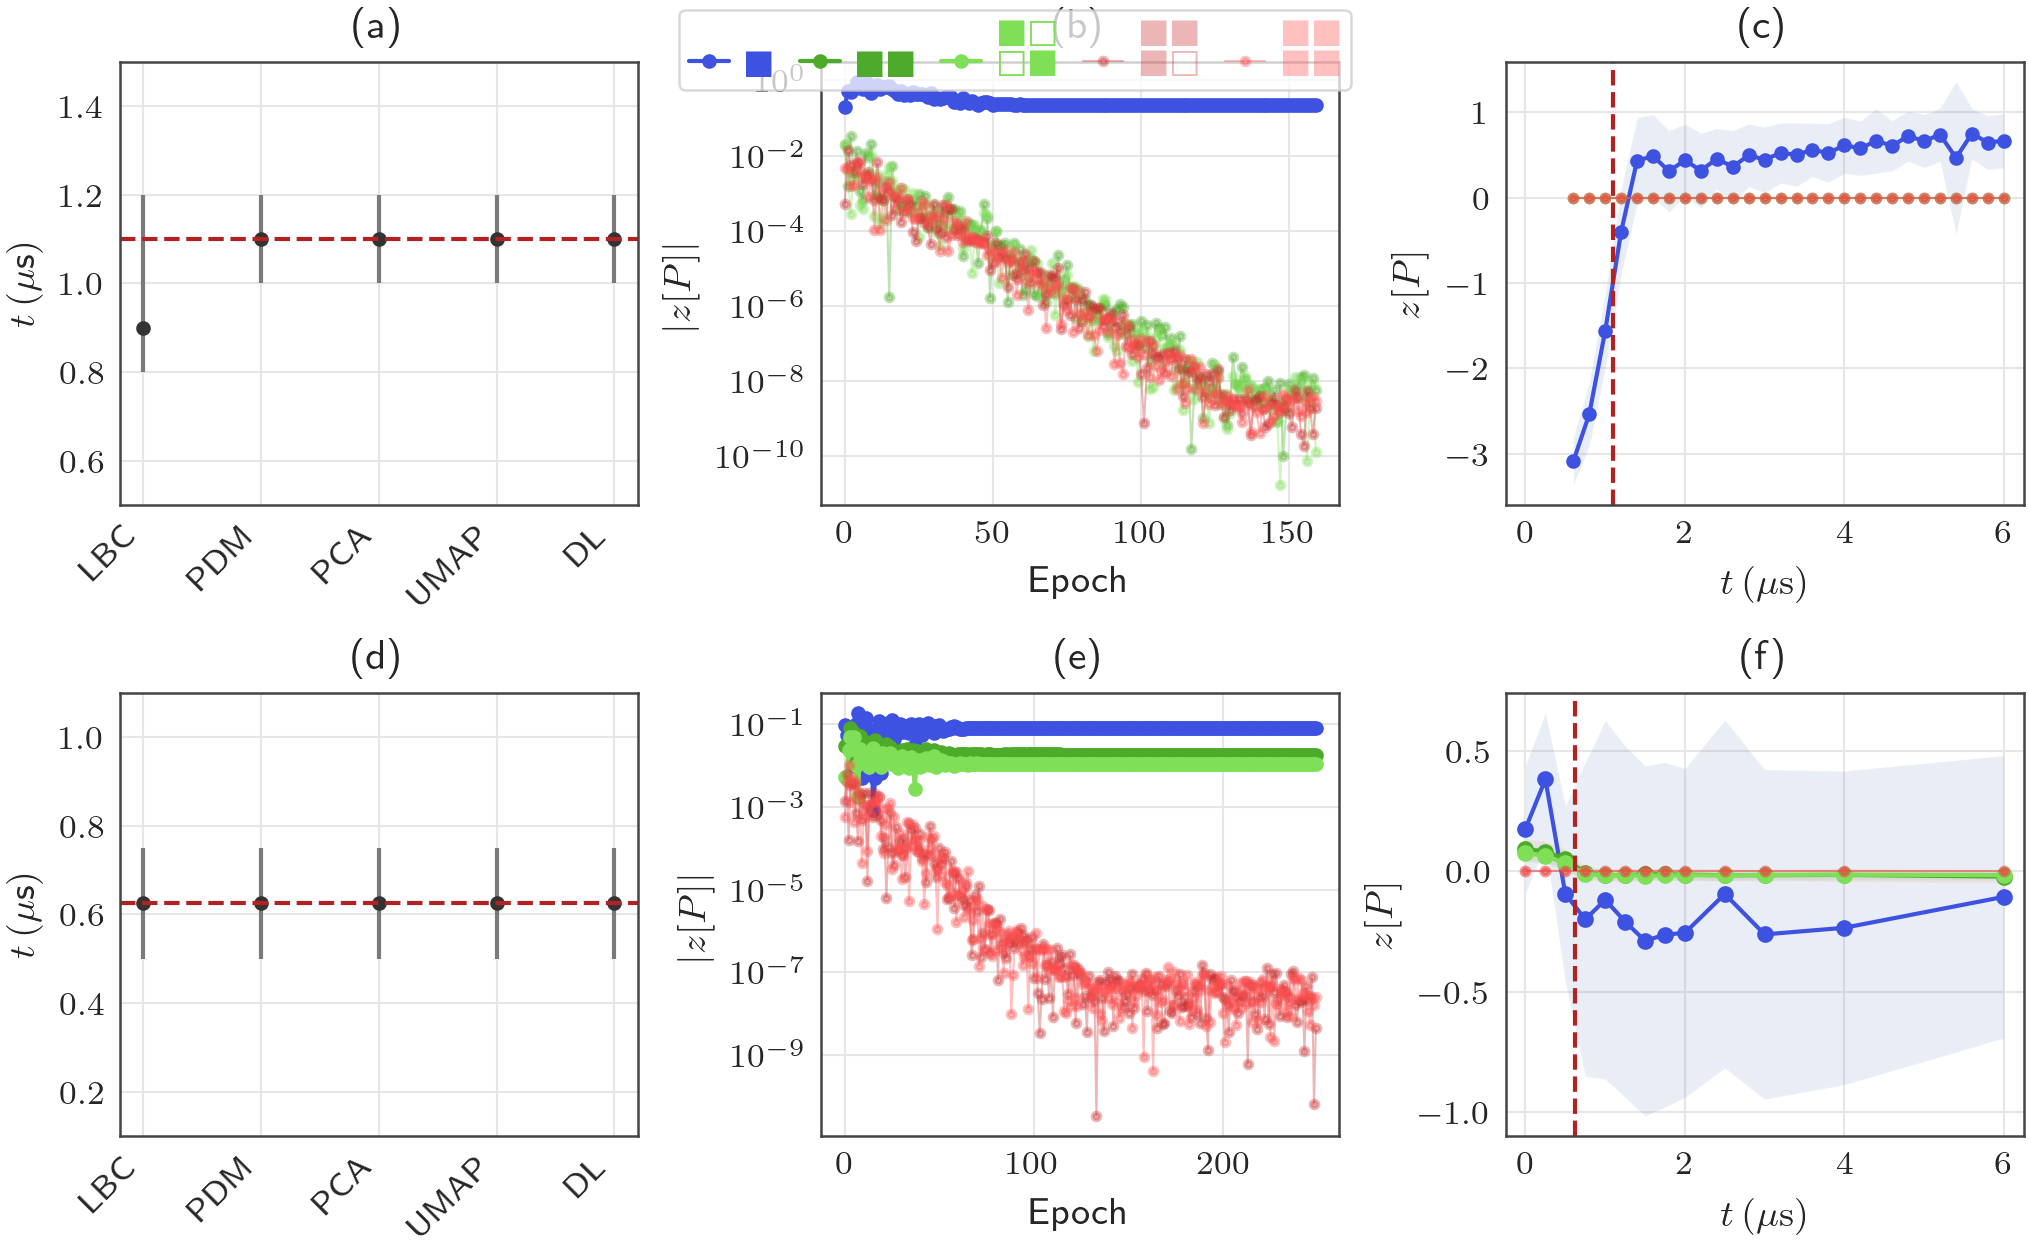

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
#  Numerical derivative comparison for Ising and XY
# ══════════════════════════════════════════════════════════════════════════════

GT_SEARCH_LO_Ising = -7.9969   # lower bound: excludes GT≈0 NN-floor artefact # Ising MODEL (Omega=0, Delta=-10)
GT_SEARCH_HI_Ising = 1.75  # upper bound: excludes sparse high-GT saturation tail # Ising MODEL (Omega=1.8, Delta=2.5)

GT_SEARCH_LO_XY = 0.25   # lower bound: excludes GT≈0 NN-floor artefact # XY MODEL
GT_SEARCH_HI_XY = 15.0  # upper bound: excludes sparse high-GT saturation tail # XY MODEL

TRIM_LEFT_Ising  = 0
TRIM_RIGHT_Ising = 22
TRIM_LEFT_XY     = 6
TRIM_RIGHT_XY    = 0
DIFF_ORDER = 1
FWHM_THRESH = 0.5
FINAL_EXCLUDED_REGION_MODE = "clip"

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.style.use(PAPER_MPLSTYLE)

DOUBLE_WIDTH = 6.80914
golden_ratio = (1 + np.sqrt(5)) / 2

important_alpha = 1.0
unimportant_alpha = 0.35

important_ising = [0]
important_xy = [0, 1, 2]

fig, axs = plt.subplot_mosaic(
    [["A", "B", "C"], ["D", "E", "F"]],
    figsize=(DOUBLE_WIDTH, DOUBLE_WIDTH / golden_ratio),
    width_ratios=[1, 1, 1],
    constrained_layout=False,
)

fig.subplots_adjust(
    left=0.08,
    right=0.995,
    bottom=0.12,
    top=0.86,
    wspace=0.35,
    hspace=0.45,
)

ax = axs["A"]

techniques_list = techniques_summary["Ising"].keys()
techniques_order = np.arange(len(techniques_list))
for i, technique in enumerate(techniques_list):
    transition, (envelope_lo, envelope_hi) = techniques_summary["Ising"][technique]
    ax.errorbar(techniques_order[i], transition / 1e3, yerr=np.array([[transition - envelope_lo], [envelope_hi - transition]]) / 1e3, fmt='none', color=COLORS["gray"], capsize=0)
    ax.plot(techniques_order[i], transition / 1e3, 'o', color=COLORS["blackish"], label=technique)
ax.axhline(transition_PBM_Ising / 1e3, color=COLORS["reddish"], ls='--', label='PBM transition')
ax.set_xticks(techniques_order)
ax.set_xticklabels(techniques_list, rotation=45, ha='right')
ax.set_ylabel(r"$t\,(\mu\text{s})$")
ax.set_ylim(0.5, 1.5)
ax.set_title("(a)")

ax = axs["D"]

techniques_list = techniques_summary["XY"].keys()
techniques_order = np.arange(len(techniques_list))
for i, technique in enumerate(techniques_list):
    transition, (envelope_lo, envelope_hi) = techniques_summary["XY"][technique]
    ax.errorbar(techniques_order[i], transition / 1e3, yerr=np.array([[transition - envelope_lo], [envelope_hi - transition]]) / 1e3, fmt='none', color=COLORS["gray"], capsize=0)
    ax.plot(techniques_order[i], transition / 1e3, 'o', color=COLORS["blackish"], label=technique)
ax.axhline(transition_PBM_XY_XZ / 1e3, color=COLORS["reddish"], ls='--', label='PBM transition')
ax.set_xticks(techniques_order)
ax.set_xticklabels(techniques_list, rotation=45, ha='right')
ax.set_ylabel(r"$t\,(\mu\text{s})$")
ax.set_ylim(0.1, 1.1)
ax.set_title("(d)")

ax = axs["B"]
important = np.zeros(len(cf_Ising_CLF.kernels))
important[important_ising] = 1
bottleneck_history = np.array([metrics_Ising_CLF[f'z_{k}'] for k in range(len(cf_Ising_CLF.kernels))])
for i in range(len(cf_Ising_CLF.kernels)):
    ax.plot(np.abs(bottleneck_history[i]), 
        color=colors[i % 10],
        marker='o',
        lw = 1.0 if important[i] else 0.5,
        ms = 2.5 if important[i] else 1.8,
        alpha=important_alpha if important[i] else unimportant_alpha,
        label=kernel_to_latex_pattern(cf_Ising_CLF.kernels[i]))
ax.set_xlabel("Epoch")
ax.set_ylabel(r"$\left|z[P]\right|$")
ax.set_yscale("log")
ax.set_title("(b)")

ax = axs["C"]
important = np.zeros(len(cf_Ising_CLF.kernels))
important[important_ising] = 1
for i in range(len(cf_Ising_CLF.kernels)):
    ax.plot(times_unique_Ising_CLF/1e3, bottlenecks_mu_Ising_CLF[:, i], 
            color=colors[i % 10],
            marker='o',
            lw = 1.0 if important[i] else 0.5,
            ms = 2.5 if important[i] else 1.8,
            alpha=important_alpha if important[i] else unimportant_alpha,
            label=kernel_to_latex_pattern(cf_Ising_CLF.kernels[i]))
    ax.fill_between(times_unique_Ising_CLF/1e3,
                    bottlenecks_mu_Ising_CLF[:, i] - bottlenecks_sigma_Ising_CLF[:, i],
                    bottlenecks_mu_Ising_CLF[:, i] + bottlenecks_sigma_Ising_CLF[:, i], alpha=0.12)
ax.axvline((times_unique_Ising_CLF[2] + times_unique_Ising_CLF[3])/2/1e3, color=COLORS["reddish"], linestyle='--')
ax.set_xlabel(r"$t\,(\mu\mathrm{s})$")
ax.set_ylabel("$z[P]$")
ax.set_xlim(-0.25, 6.25)
ax.set_title("(c)")

ax = axs["E"]
important = np.zeros(len(cf_XY_CLF.kernels))
important[important_xy] = 1
bottleneck_history = np.array([metrics_XY_CLF[f'z_{k}'] for k in range(len(cf_XY_CLF.kernels))])
for i in range(len(cf_XY_CLF.kernels)):
    ax.plot(np.abs(bottleneck_history[i]), 
            color=colors[i % 10],
            marker='o',
            lw = 1.0 if important[i] else 0.5,
            ms = 2.5 if important[i] else 1.8,
            alpha=important_alpha if important[i] else unimportant_alpha,
            label=kernel_to_latex_pattern(cf_XY_CLF.kernels[i]))
    
with plt.rc_context({'text.usetex': False}):
    legend = ax.legend(ncol=10, framealpha=0.75)
for text, line in zip(legend.get_texts(), legend.get_lines()):
    text.set_color(line.get_color())
ax.set_xlabel("Epoch")
ax.set_ylabel(r"$\left|z[P]\right|$")
ax.set_yscale("log")
ax.set_title("(e)")

with plt.rc_context({'text.usetex': False}):
    existing_legend = ax.get_legend() 

    handles = existing_legend.legend_handles
    labels  = [t.get_text() for t in existing_legend.get_texts()]
    colors = [line.get_color() for line in existing_legend.get_lines()]
    new_legend = fig.legend(
        handles, labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=10,
        framealpha=0.75,
    )

    it = 0
    for text, line in zip(new_legend.get_texts(), new_legend.get_lines()):
        text.set_color(line.get_color())
        alpha = (
            important_alpha
            if it in important_xy
            else unimportant_alpha
        )
        text.set_alpha(alpha)
        it += 1

    existing_legend.remove()

ax = axs["F"]
important = np.zeros(len(cf_XY_CLF.kernels))
important[important_xy] = 1
for i in range(len(cf_XY_CLF.kernels)):
    ax.plot(times_unique_XY_CLF/1e3, bottlenecks_mu_XY_CLF[:, i], 
            color=colors[i % 10],
            marker='o',
            lw = 1.0 if important[i] else 0.5,
            ms = 3.0 if important[i] else 1.8,
            alpha=important_alpha if important[i] else unimportant_alpha,
            label=kernel_to_latex_pattern(cf_XY_CLF.kernels[i]))
    ax.fill_between(times_unique_XY_CLF/1e3,
                    bottlenecks_mu_XY_CLF[:, i] - bottlenecks_sigma_XY_CLF[:, i],
                    bottlenecks_mu_XY_CLF[:, i] + bottlenecks_sigma_XY_CLF[:, i], alpha=0.12)
ax.axvline((times_unique_XY_CLF[3] + times_unique_XY_CLF[2])/2/1e3, color=COLORS["reddish"], linestyle='--')
ax.set_xlabel(r"$t\,(\mu\mathrm{s})$")
ax.set_ylabel("$z[P]$")
ax.set_xlim(-0.25, 6.25)
ax.set_title("(f)")

fig.savefig("Plots/Fig4.pdf")